# Scan Map Visualizer

Load and compare the three generated map images in `scan_map/maps/`: `raw_map.pgm`, `lidar_map.pgm`, and `planner_map.pgm`.

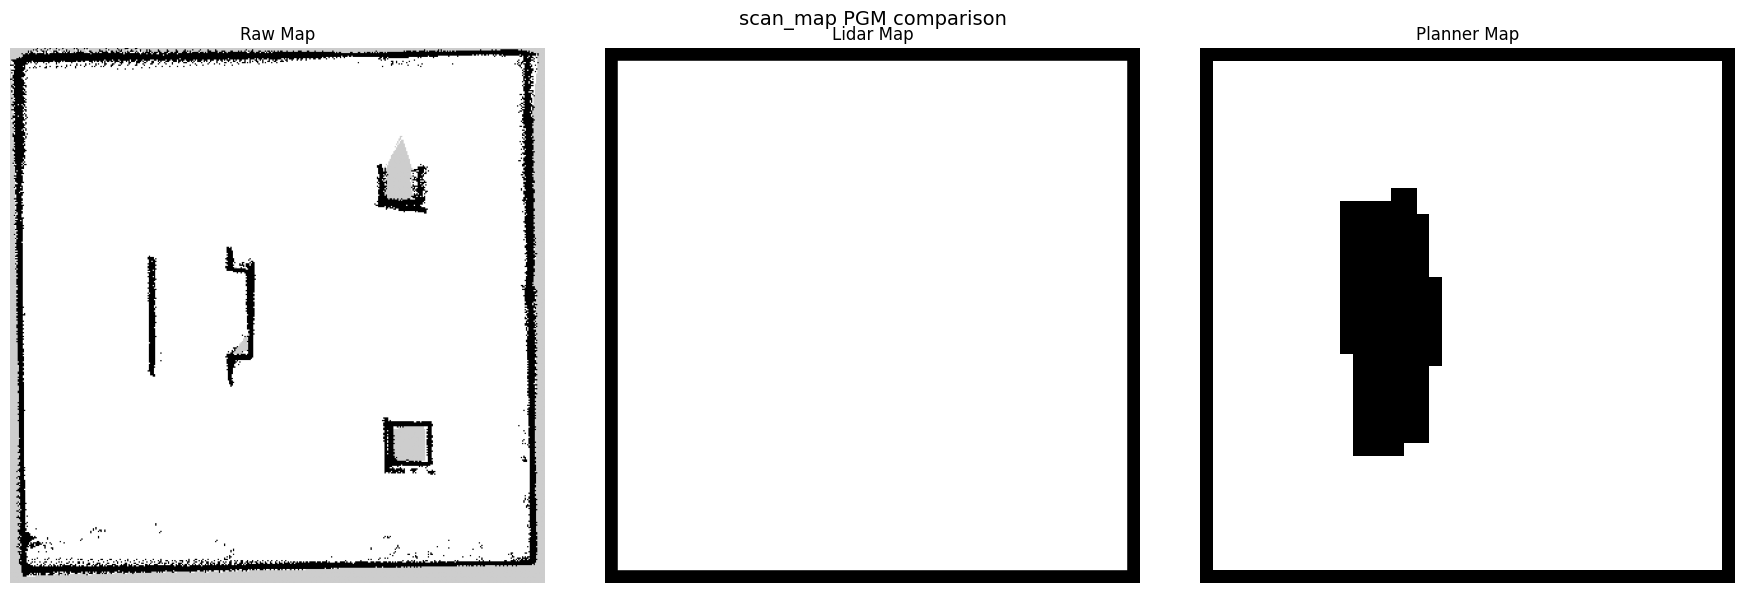

In [3]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt


def find_map_dir() -> Path:
    candidates = [
        Path.cwd() / 'scan_map' / 'maps',
        Path.cwd(),
        Path.cwd().parent / 'scan_map' / 'maps',
    ]
    for candidate in candidates:
        if (candidate / 'raw_map.pgm').exists():
            return candidate
    raise FileNotFoundError('Could not find scan_map/maps with raw_map.pgm')


def load_map(path: Path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f'Could not read map image: {path}')
    return image


map_dir = find_map_dir()
map_paths = [map_dir / name for name in ('raw_map.pgm', 'lidar_map.pgm', 'planner_map.pgm')]
images = [load_map(path) for path in map_paths]

fig, axes = plt.subplots(1, len(images), figsize=(6 * len(images), 6), squeeze=False)
for axis, path, image in zip(axes[0], map_paths, images):
    axis.imshow(image, cmap='gray', vmin=0, vmax=255)
    axis.set_title(path.stem.replace('_', ' ').title())
    axis.axis('off')

fig.suptitle('scan_map PGM comparison', fontsize=14)
fig.tight_layout()
plt.show()